In [1]:
import torch
import numpy as np
import os
from PIL import Image
import cv2
from matplotlib import pyplot as plt
from matplotlib import rc
import platform
import re
from paddleocr import PaddleOCR, draw_ocr

from src.find_truck_license_plate import load_model_license_plate, find_truck_license_plate
from src.yolov_test import process_yolo
from src.levenshtein import levenshtein_similarity
from src.levenshtein_test import levenshtein_similarity_test

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_findLP = load_model_license_plate(device)
#ocr = PaddleOCR(lang="korean")
ocr = PaddleOCR(lang="korean", use_angle_cls=False, show_log=False)

c:\Users\user\anaconda3\envs\LP\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
YOLOv5  2025-2-5 Python-3.9.21 torch-1.13.1+cu117 CUDA:0 (NVIDIA GeForce RTX 2070, 8192MiB)

Fusing layers... 
Model summary: 212 layers, 20852934 parameters, 0 gradients, 47.9 GFLOPs
Adding AutoShape... 


In [2]:
folder_path = './data/images/0.truck'
img_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
img_truck = []
number_truck = []
for i, img_file in enumerate(img_files):
    img_path = os.path.join(folder_path, img_file)
    img = Image.open(img_path)
    img = np.array(img)
    base_name = img_file.split('.')[0]
    base_name = base_name.split('_')[1]
    img_truck.append(img)
    number_truck.append(base_name)


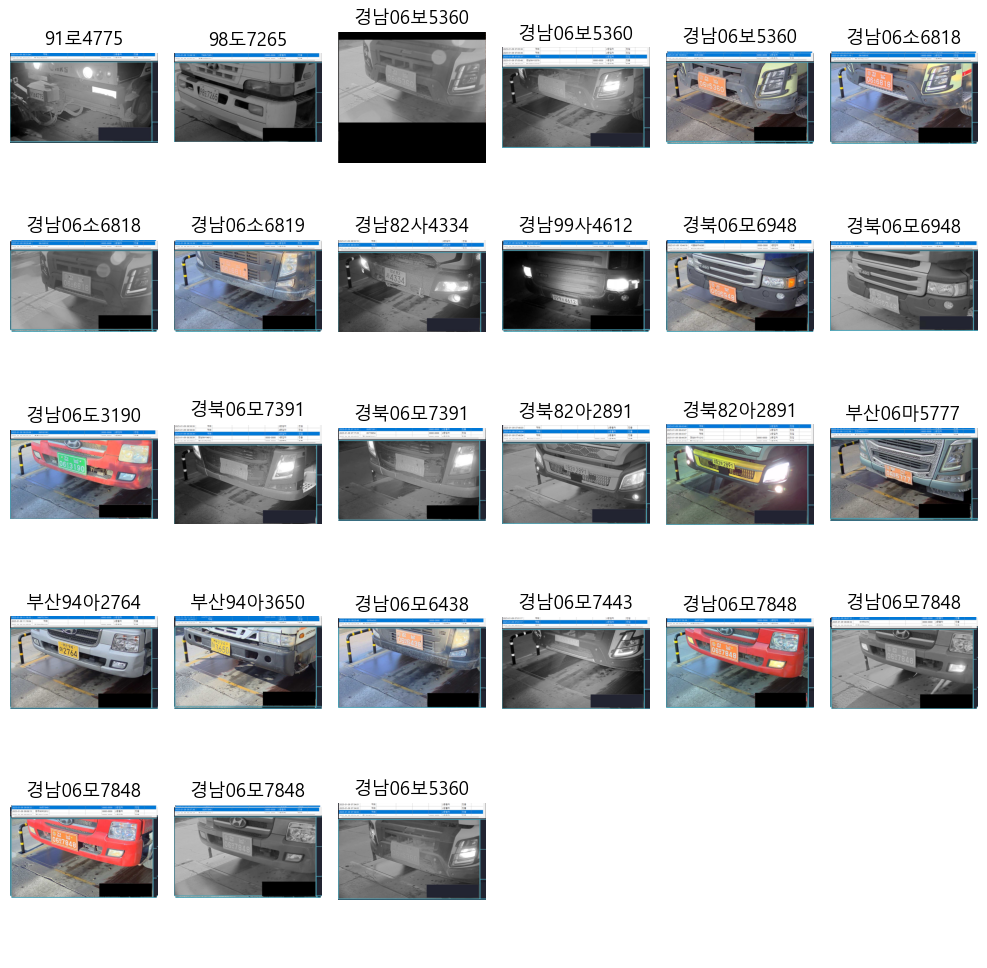

In [12]:
%matplotlib inline
num_columns = 6  # 예: 3개씩 보여주기
num_rows = 5
fig, axes = plt.subplots(num_rows, num_columns, figsize=(10, 10))
axes = axes.ravel()

# 이미지 출력 설정
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')  # Windows의 경우
elif platform.system() == 'Darwin':  # macOS의 경우
    rc('font', family='AppleGothic')
else:  # Linux의 경우
    rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


for i, (img, number) in enumerate(zip(img_truck, number_truck)):
    
    # 각 이미지에 대해 서브플롯에 표시
    axes[i].imshow(img)
    axes[i].set_title(number)
    axes[i].axis('off')  # 축을 숨김

# 남은 서브플롯 비우기 (이미지가 없으면 빈 공간으로 처리)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# 레이아웃 조정 (여백 없애기)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.tight_layout()  # 레이아웃 간격을 자동으로 맞추기
plt.show()  # 모든 이미지를 화면에 표시

#트럭이미지에서 번호판 추출

In [4]:
license_plate = [] 
numbers = []
for i, img in enumerate(img_truck):
    license_plate_detection = find_truck_license_plate(img, model_findLP)
    Predicted_number = ''
    result = ocr.ocr(license_plate_detection, cls=False)
    ocr_result = result[0]
    if ocr_result is not None:  # result[1]이 None이 아닐 때만 처리
        for result in ocr_result:
            Predicted_number += result[1][0]
    number = re.sub(r'[^0-9]', '', Predicted_number)
    license_plate.append(license_plate_detection)
    numbers.append(number)


#추출된 번호판 이미지

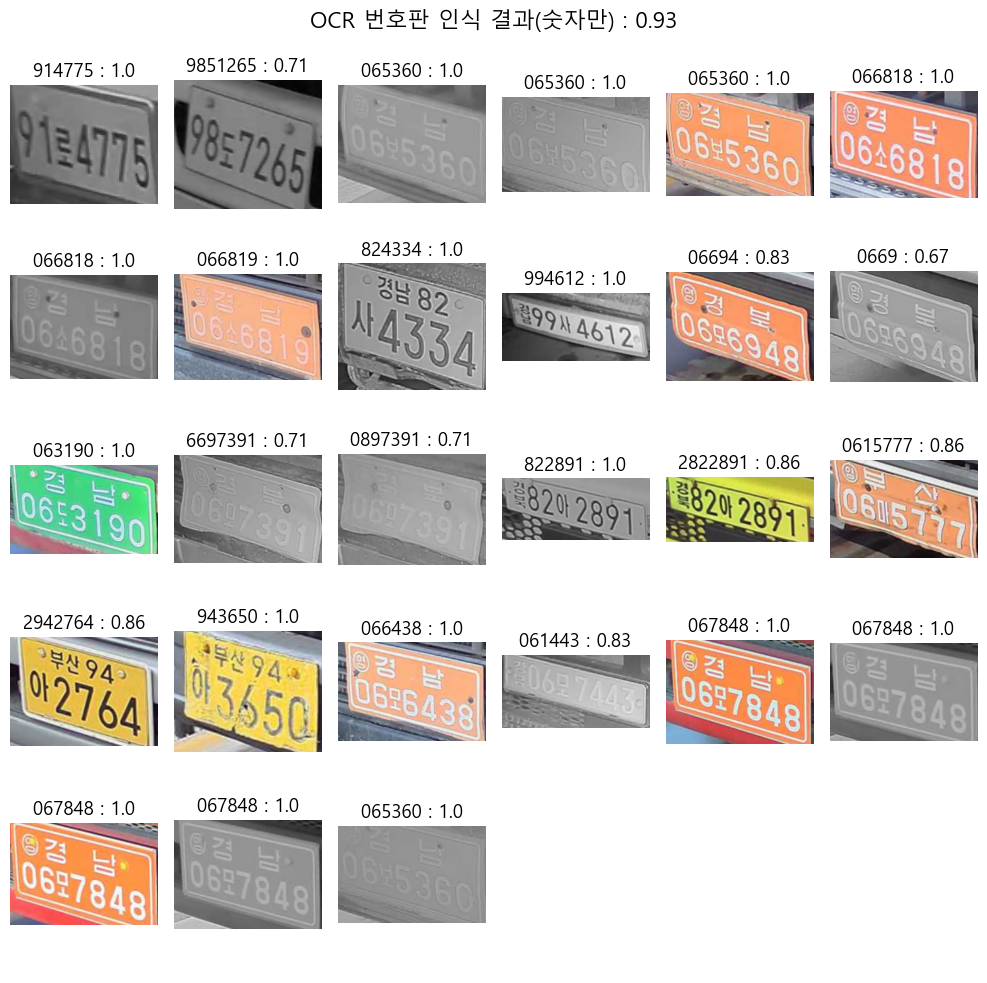

In [5]:
%matplotlib inline
num_columns = 6  # 예: 3개씩 보여주기
num_rows = 5
fig, axes = plt.subplots(num_rows, num_columns, figsize=(10, 10))
axes = axes.ravel()
confidences = 0

# 이미지 출력 설정
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')  # Windows의 경우
elif platform.system() == 'Darwin':  # macOS의 경우
    rc('font', family='AppleGothic')
else:  # Linux의 경우
    rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


for i, (img, number, Predicted_number) in enumerate(zip(license_plate, number_truck, numbers)):
    number = re.sub(r'[^0-9]', '', number)
    confidence = levenshtein_similarity_test(number,Predicted_number)
    confidences += confidence
    text = Predicted_number + " : " + str(round(confidence,2))
    # 각 이미지에 대해 서브플롯에 표시
    axes[i].imshow(img)
    axes[i].set_title(text)
    axes[i].axis('off')  # 축을 숨김
confidences = round(confidences / 27,2)
# 남은 서브플롯 비우기 (이미지가 없으면 빈 공간으로 처리)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# 레이아웃 조정 (여백 없애기)
plt.suptitle(f"OCR 번호판 인식 결과(숫자만) : {confidences}", fontsize=16)  # 전체 제목 추가
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.tight_layout()  # 레이아웃 간격을 자동으로 맞추기
plt.show()  # 모든 이미지를 화면에 표시

#번호판이미지에서 문자열 인식

In [6]:
img_recognitions = []
img_boxs = []
img_processings = []
number_predicts = []
gamma = 0.8
inv_gamma = 1.0 / gamma
lut = np.array([((j / 255.0) ** inv_gamma) * 255 for j in range(256)]).astype('uint8')
for i, (img, car_number) in enumerate(zip(license_plate, number_truck)):
    img = np.array(img)
    img = cv2.LUT(img, lut)
    img_recognition, img_box, img_processing, number_predict = process_yolo(img)
    img_recognitions.append(img_recognition)
    img_boxs.append(img_box)
    img_processings.append(img_processing)
    number_predicts.append(number_predict)

Using cache found in C:\Users\user/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2025-1-27 Python-3.9.21 torch-1.13.1+cu117 CUDA:0 (NVIDIA GeForce RTX 2070, 8192MiB)

Fusing layers... 
YOLOv5s summary: 214 layers, 7027720 parameters, 0 gradients, 16.0 GFLOPs
Adding AutoShape... 
Using cache found in C:\Users\user/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2025-1-27 Python-3.9.21 torch-1.13.1+cu117 CUDA:0 (NVIDIA GeForce RTX 2070, 8192MiB)

Fusing layers... 
YOLOv5s summary: 214 layers, 7027720 parameters, 0 gradients, 16.0 GFLOPs
Adding AutoShape... 
Using cache found in C:\Users\user/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2025-1-27 Python-3.9.21 torch-1.13.1+cu117 CUDA:0 (NVIDIA GeForce RTX 2070, 8192MiB)

Fusing layers... 
YOLOv5s summary: 214 layers, 7027720 parameters, 0 gradients, 16.0 GFLOPs
Adding AutoShape... 
Using cache found in C:\Users\user/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2025-1-27 Python-3.9.21 torch-1.13.1+cu117 CUDA:0 (NVIDIA G

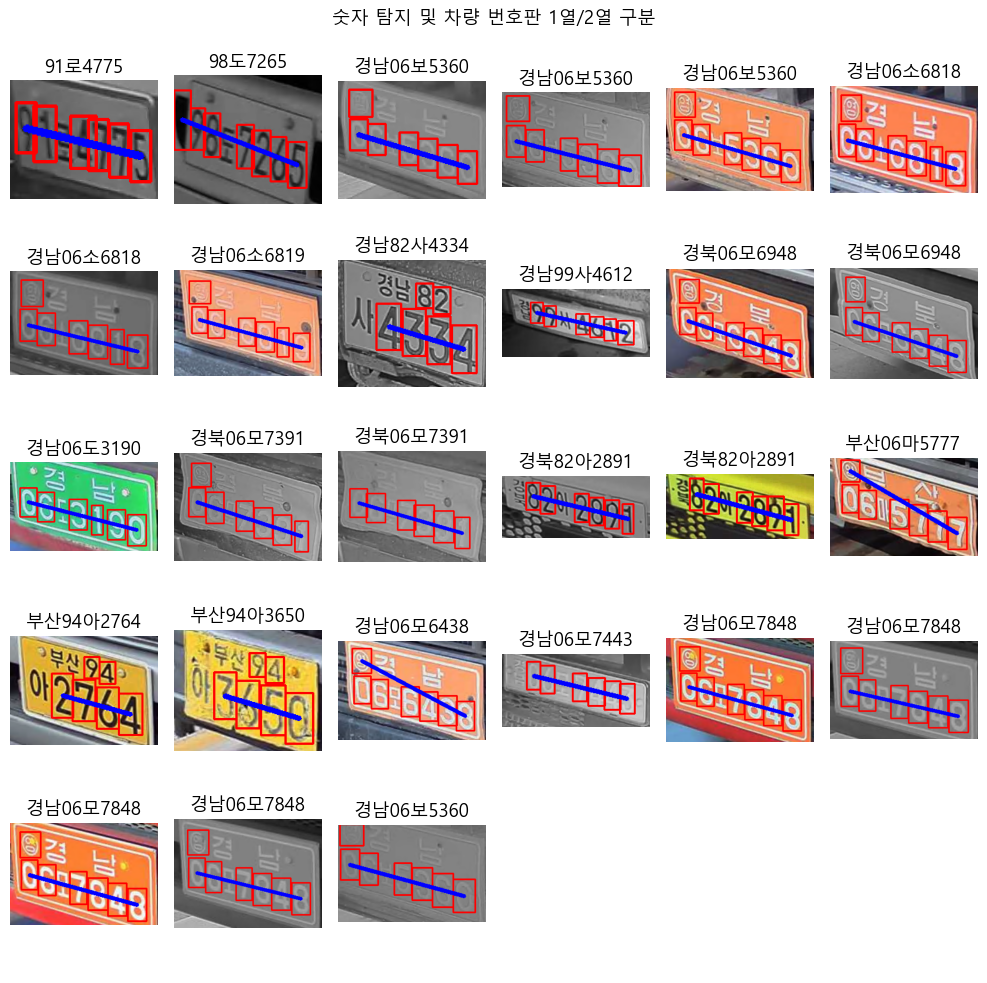

In [13]:
%matplotlib inline
num_columns = 6  # 예: 3개씩 보여주기
num_rows = 5
fig, axes = plt.subplots(num_rows, num_columns, figsize=(10, 10))
axes = axes.ravel()

# 이미지 출력 설정
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')  # Windows의 경우
elif platform.system() == 'Darwin':  # macOS의 경우
    rc('font', family='AppleGothic')
else:  # Linux의 경우
    rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


for i, (img, number) in enumerate(zip(img_recognitions, number_truck)):
    
    # 각 이미지에 대해 서브플롯에 표시
    axes[i].imshow(img)
    axes[i].set_title(number)
    axes[i].axis('off')  # 축을 숨김

# 남은 서브플롯 비우기 (이미지가 없으면 빈 공간으로 처리)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# 레이아웃 조정 (여백 없애기)
plt.suptitle(f"숫자 탐지 및 차량 번호판 1열/2열 구분")  # 전체 제목 추가
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.tight_layout()  # 레이아웃 간격을 자동으로 맞추기
plt.show()  # 모든 이미지를 화면에 표시

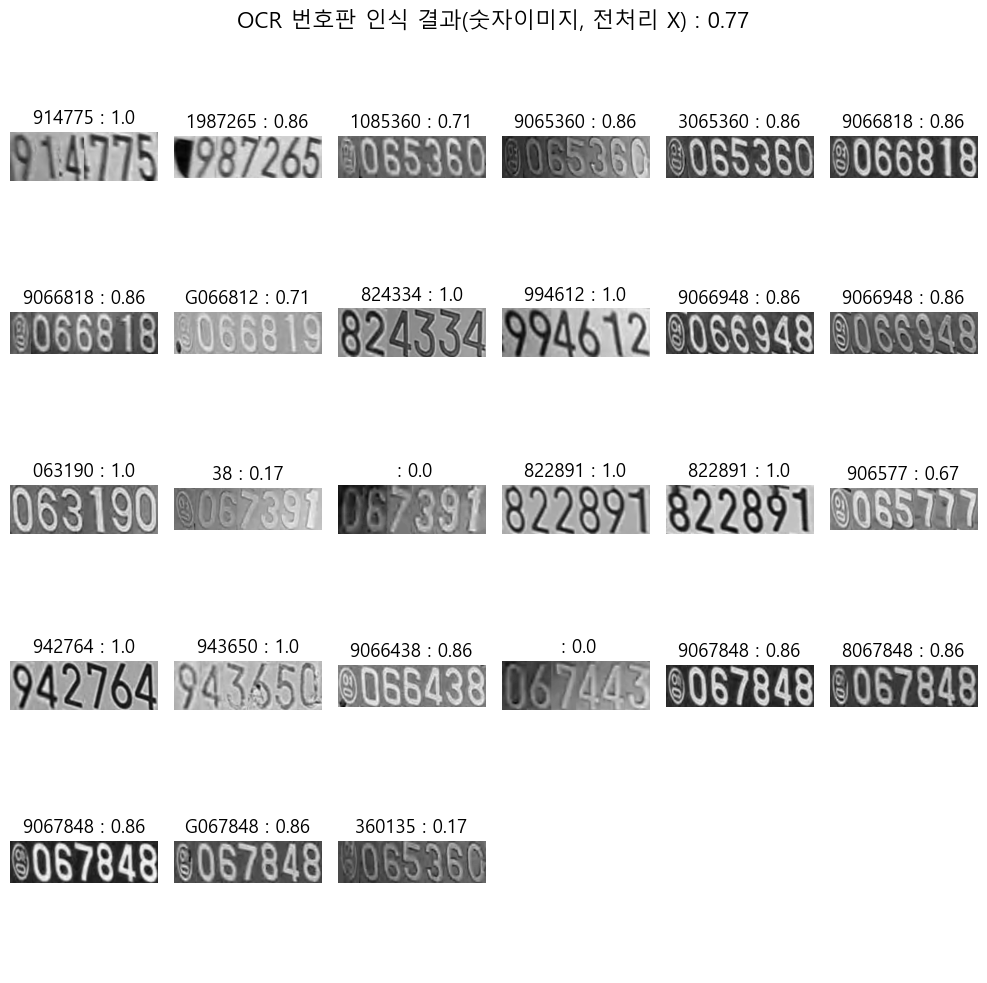

In [8]:
%matplotlib inline
num_columns = 6  # 예: 3개씩 보여주기
num_rows = 5
fig, axes = plt.subplots(num_rows, num_columns, figsize=(10, 10))
axes = axes.ravel()
confidences = 0
# 이미지 출력 설정
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')  # Windows의 경우
elif platform.system() == 'Darwin':  # macOS의 경우
    rc('font', family='AppleGothic')
else:  # Linux의 경우
    rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

for i, (img, number) in enumerate(zip(img_boxs, number_truck)):
    Predicted_number = ''
    result = ocr.ocr(img, cls=False)
    ocr_result = result[0]
    if ocr_result is not None:  # result[1]이 None이 아닐 때만 처리
        for result in ocr_result:
            Predicted_number += result[1][0]
    number = re.sub(r'[^0-9]', '', number)
    confidence = levenshtein_similarity_test(Predicted_number,number)
    confidences += confidence
    text = Predicted_number + " : " + str(round(confidence,2))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(text)
    axes[i].axis('off')  # 축을 숨김

confidences = round(confidences / 27,2)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f"OCR 번호판 인식 결과(숫자이미지, 전처리 X) : {confidences}", fontsize=16)  # 전체 제목 추가
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.tight_layout() 
plt.show()  

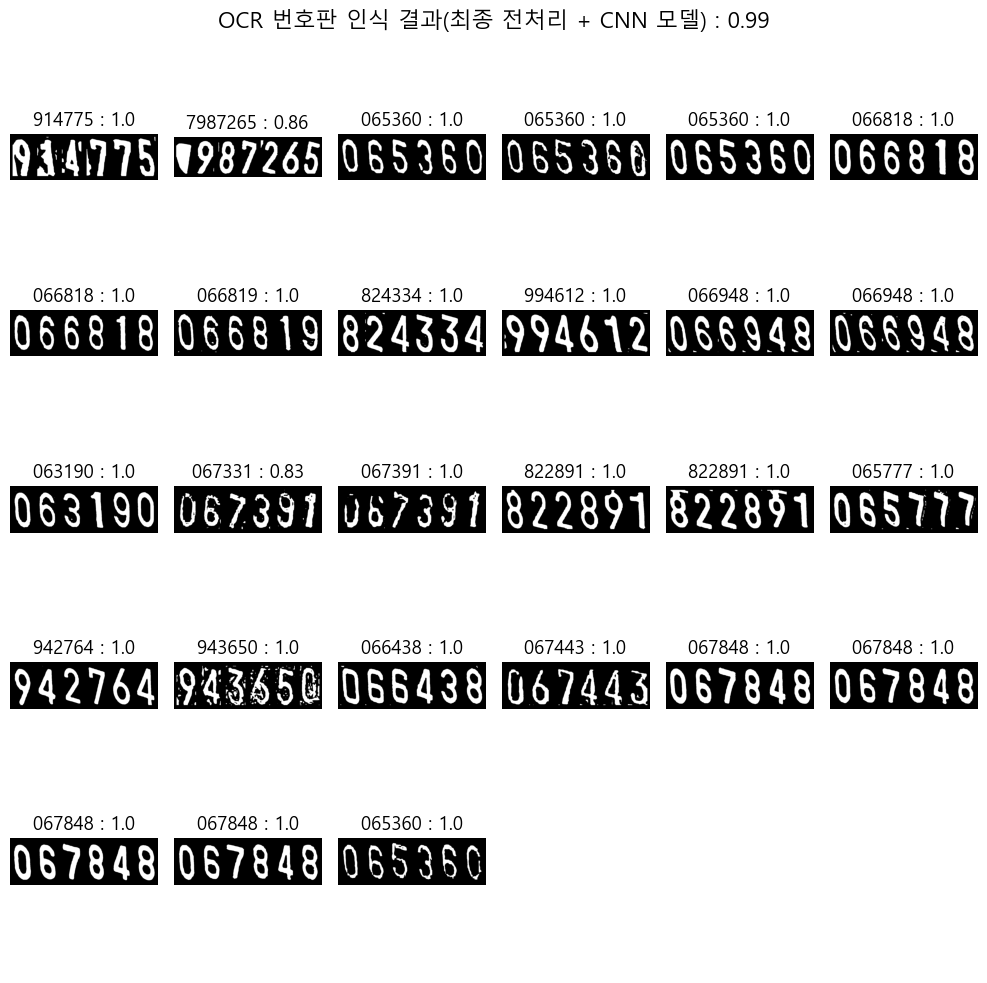

In [9]:
%matplotlib inline
num_columns = 6  # 예: 3개씩 보여주기
num_rows = 5
fig, axes = plt.subplots(num_rows, num_columns, figsize=(10, 10))
axes = axes.ravel()
confidences = 0
# 이미지 출력 설정
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')  # Windows의 경우
elif platform.system() == 'Darwin':  # macOS의 경우
    rc('font', family='AppleGothic')
else:  # Linux의 경우
    rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

for i, (img, number, number1) in enumerate(zip(img_processings, number_truck, number_predicts)):
    Predicted_number = ''
    result = ocr.ocr(img, cls=False)
    ocr_result = result[0]
    if ocr_result is not None:  # result[1]이 None이 아닐 때만 처리
        for result in ocr_result:
            Predicted_number += result[1][0]
    number = re.sub(r'[^0-9]', '', number)
    confidence = levenshtein_similarity_test(number1,number)
    confidences += confidence
    text = number1 + " : " + str(round(confidence,2))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(text)
    axes[i].axis('off')  # 축을 숨김

confidences = round(confidences / 27,2)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f"OCR 번호판 인식 결과(최종 전처리 + CNN 모델) : {confidences}", fontsize=16)  # 전체 제목 추가
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.tight_layout() 
plt.show()  

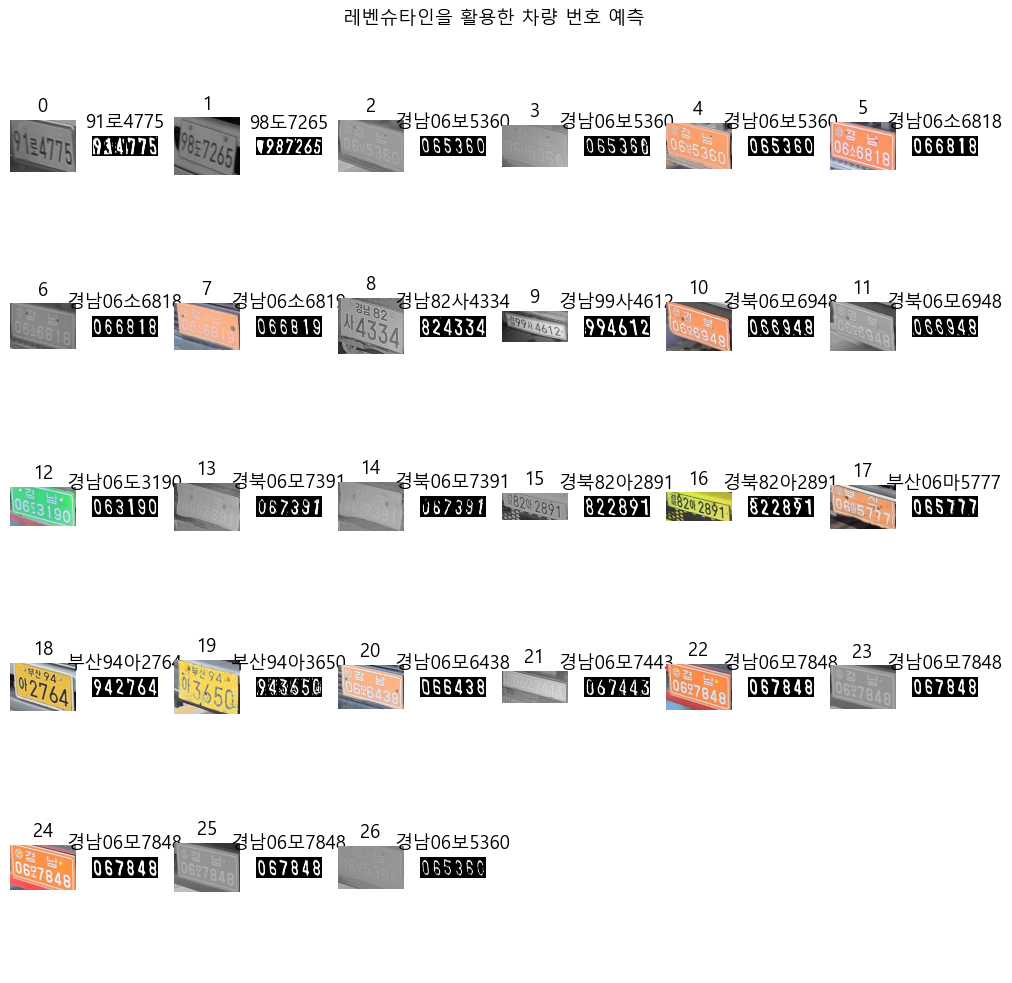

In [11]:
%matplotlib inline

# 이미지 출력 설정
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')  # Windows의 경우
elif platform.system() == 'Darwin':  # macOS의 경우
    rc('font', family='AppleGothic')
else:  # Linux의 경우
    rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

num_columns = 6  # 예: 3개씩 보여주기
num_rows = 5
fig, axes = plt.subplots(num_rows, num_columns * 2, figsize=(10, 10))
#axes = axes.ravel()
confidences = 0

for i,(img,img1,number, number1) in enumerate(zip(license_plate, img_processings, number_predicts, number_truck)):

    ax1 = axes[i // num_columns, (i % num_columns) * 2]  # 왼쪽 칸
    ax1.imshow(img)  # ✅ 컬러 이미지 출력
    ax1.set_title(i)
    ax1.axis('off')
    number = levenshtein_similarity(number)
    # ✅ 두 번째 칸: 처리된 이미지
    ax2 = axes[i // num_columns, (i % num_columns) * 2 + 1]  # 오른쪽 칸
    ax2.imshow(img1, cmap='gray')  # ✅ 흑백 이미지 출력
    ax2.set_title(number)
    ax2.axis('off')

# 남은 subplot 비우기
for j in range(i + 1, num_rows * num_columns):
    axes[j // num_columns, (j % num_columns) * 2].axis('off')
    axes[j // num_columns, (j % num_columns) * 2 + 1].axis('off')

plt.suptitle(f"레벤슈타인을 활용한 차량 번호 예측")  # 전체 제목 추가
plt.tight_layout()  # 서브플롯 간격 자동 조정
plt.show()
